# FRED through navi's client — the vendor envelope, unretouched

`FredClient` (`navi/lib/clients/fred.py`) is a thin async wrapper over the FRED
REST API: a single `_get` that attaches the API key and `file_type=json`, and
seven methods that hand each response to a pydantic model. It is the layer the
MCP server itself sits on top of.

This notebook is `walkthrough.ipynb`'s counterpart — the same arc, descend the
category tree, pick a series, plot it — with the server taken out of the middle.
Nothing has to be running: the calls below go straight to `api.stlouisfed.org`.
What does have to be in place is the credential, `FRED_API_KEY` in navi's
`.env`, since `lib.env.get_fred_api_key` raises if it is unset.

What is worth watching, because the MCP layer smooths it away, is how little the
client changes what FRED sends. `SeriesResponse` carries a field literally named
`seriess` — FRED's own misspelling of the plural, kept. Observation values are
strings, and a missing one is `"."` rather than `null`. The typed layer parses
and validates; it does not tidy.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

from matplotlib import pyplot
sys.path.append("../../")   # repo root, for `clients`
from lib import config
from clients import FredClient
from lib.utils import print_json_vertical

from utils import (
    fred_client_observations_to_arrays,
    plot_fred_client_series,
)

pyplot.style.use(config.glyfish_style)

## 1. Discovery

FRED is a tree, not a search index. Every series hangs off a category, the root
of the tree is `category_id` 0, and `get_category_children` is the only way
down. Depth is not uniform and a category can hold child categories *and*
series of its own, so the walk stops when a category answers with series rather
than with more children.

Descending by *name* rather than by id keeps the descent honest: the only
literals below are labels a person would read off the screen, and every id is
taken out of the response that named it.

`CategoryResponse` is where a fix made earlier today shows. Its
`realtime_start` and `realtime_end` are `Optional`, because FRED's category
endpoints send no realtime window at all, unlike `/series` and `/releases`;
inherited as required, they made `get_category_children` raise
`ValidationError` on every real response. `count` is `None` here for the same
reason — these endpoints report no total, so what comes back is all there is.

In [2]:
PATH = ("Money, Banking, & Finance", "Interest Rates", "Interest Rate Spreads")


async def descend(client, names, category_id=0):
    """Walk the category tree by name, printing each level on the way down."""
    for name in names:
        response = await client.get_category_children(category_id)
        print(f"category {category_id}: {len(response.categories)} children, "
              f"realtime_start={response.realtime_start}, count={response.count}")
        chosen = next(child for child in response.categories if child.name == name)
        for child in response.categories:
            marker = "->" if child.id == chosen.id else "  "
            print(f"  {marker} {child.id:>6}  {child.name}")
        print()
        category_id = chosen.id
    return category_id


async with FredClient() as client:
    spreads_id = await descend(client, PATH)

print(f"descent ends at category {spreads_id}")

category 0: 8 children, realtime_start=None, count=None
  ->  32991  Money, Banking, & Finance
         10  Population, Employment, & Labor Markets
      32992  National Accounts
          1  Production & Business Activity
      32455  Prices
      32263  International Data
       3008  U.S. Regional Data
      33060  Academic Data

category 32991: 7 children, realtime_start=None, count=None
  ->     22  Interest Rates
         15  Exchange Rates
         24  Monetary Data
         46  Financial Indicators
         23  Banking
      32360  Business Lending
      32145  Foreign Exchange Intervention

category 22: 25 children, realtime_start=None, count=None
      34009  AMERIBOR Benchmark Rates
      33058  Automobile Loan Rates
         51  Bankers Acceptance Rate
        121  Certificates of Deposit
        120  Commercial Paper
      32348  Corporate Bonds
      33059  Credit Card Loan Rates
      34005  EONIA Rates
      34007  Euro Short-Term Rate
      32298  Eurodollar Deposits
 

The descent stops at *Interest Rate Spreads*: it has no children, and
`get_category_series` answers with a list.

`SeriesResponse` is the vendor envelope with nothing renamed. Around the list
sit `realtime_start`, `realtime_end`, `order_by`, `sort_order`, `count`,
`offset` and `limit` — and the list itself is `seriess`. That is FRED's spelling
and the client keeps it; the MCP server's own response model is the layer that
renames it to `series`. Reaching for `response.seriess` is the tell that you are
below the server.

The defaults are the vendor's here too. FRED's `limit` is 1000 on a listing
endpoint and 100000 on observations, so the 36-row listing below arrives whole
without asking for anything. The MCP tool's `limit=100` is meida's choice, not
FRED's, and it does not reach this notebook. `count` is FRED's total for the query while the list is only what this
call returned, so `count != len(seriess)` is how truncation would announce
itself.

FRED's default sort is ascending, so asking it to order by popularity would hand
back the *least* used series first. At 36 rows the honest fix is to sort what
came back. Popularity is FRED's 0–100 usage score, a decent proxy for the series
people mean when they name a thing.

In [3]:
async with FredClient() as client:
    catalog = await client.get_category_series(spreads_id)

print(f"envelope: order_by={catalog.order_by!r}, sort_order={catalog.sort_order!r}, "
      f"count={catalog.count}, offset={catalog.offset}, limit={catalog.limit}")
print(f"{catalog.count} series in the category, {len(catalog.seriess)} returned\n")

for entry in sorted(catalog.seriess, key=lambda s: -(s.popularity or 0))[:8]:
    frequency = entry.frequency_short or ""
    units = entry.units_short or ""
    print(f"{entry.id:8s} {entry.popularity or 0:>3}  {frequency:2s} {units:2s} "
          f"{entry.observation_start} .. {entry.observation_end}  {entry.title[:58]}")

envelope: order_by='series_id', sort_order='asc', count=36, offset=0, limit=1000
36 series in the category, 36 returned

T10Y2Y    98  D  %  1976-06-01 .. 2026-09-04  10-Year Treasury Constant Maturity Minus 2-Year Treasury C
T10Y3M    92  D  %  1982-01-04 .. 2026-09-04  10-Year Treasury Constant Maturity Minus 3-Month Treasury 
T10YIE    91  D  %  2003-01-02 .. 2026-09-04  10-Year Breakeven Inflation Rate
T5YIE     85  D  %  2003-01-02 .. 2026-09-04  5-Year Breakeven Inflation Rate
T5YIFR    83  D  %  2003-01-02 .. 2026-09-04  5-Year, 5-Year Forward Inflation Expectation Rate
BAA10Y    78  D  %  1986-01-02 .. 2026-09-03  Moody's Seasoned Baa Corporate Bond Yield Relative to Yiel
T10YFF    67  D  %  1962-01-02 .. 2026-09-03  10-Year Treasury Constant Maturity Minus Federal Funds Rat
T30YIEM   63  M  %  2010-02-01 .. 2026-08-01  30-year Breakeven Inflation Rate


The category tree is one way into the catalog and the client carries two
more. `get_releases` and `get_release_series` partition FRED by *publication* —
everything the Fed issues in the H.15 release, say — and `get_series_updates`
answers "what changed recently". All three come back in the same envelope:
releases in a `ReleasesResponse`, the other two in the `SeriesResponse` already
seen.

The two axes are not the same cut of the catalog. H.15 publishes `DGS10` and
`DGS2`, the two legs of the spread found above, but not the spread itself, which
FRED computes. Series that exist in a category need not exist in a release.

`get_series_updates` is where the pagination fields finally earn their place:
`count` runs to six figures against a returned page of five, which is exactly
the `count != len(seriess)` case the envelope exists to make visible.

In [4]:
async with FredClient() as client:
    releases = await client.get_releases()
    h15 = next(release for release in releases.releases if release.name.startswith("H.15"))
    print(f"{releases.count} releases; H.15 is release {h15.id}, {h15.name!r}")
    print(f"  press_release={h15.press_release}, link={h15.link}")

    published = await client.get_release_series(h15.id)
    ids = {entry.id for entry in published.seriess}
    print(f"  {published.count} series in it, {len(published.seriess)} returned")
    for candidate in ("DGS10", "DGS2", "T10Y2Y"):
        print(f"    {candidate:8s} in H.15: {candidate in ids}")

    updates = await client.get_series_updates(limit=5)

print(f"\n{updates.count} series in FRED's update window, {len(updates.seriess)} returned")
for entry in updates.seriess:
    print(f"  {entry.id:20s} {entry.last_updated:%Y-%m-%d %H:%M:%S}  {entry.title[:44]}")

331 releases; H.15 is release 18, 'H.15 Selected Interest Rates'
  press_release=True, link=http://www.federalreserve.gov/releases/h15/
  270 series in it, 270 returned
    DGS10    in H.15: True
    DGS2     in H.15: True
    T10Y2Y   in H.15: False

110946 series in FRED's update window, 5 returned
  JPNNGDP              2026-09-07 18:52:32  Gross Domestic Product for Japan
  JPNRGDPEXP           2026-09-07 18:52:32  Real Gross Domestic Product for Japan
  JPNRGDPNGS           2026-09-07 18:52:31  Real Net Exports of Good and Services for Ja
  JPNRGDPIGS           2026-09-07 18:52:31  Real Imports of Goods and Services for Japan
  JPNRGDPEGS           2026-09-07 18:52:31  Real Exports of Goods and Services for Japan


## 2. Retrieving a series

`T10Y2Y` is the 10-year Treasury constant maturity minus the 2-year: the slope
of the front of the yield curve, daily since June 1976. It is the series people
mean by "the curve inverted", and it carries its own history in one line, deeply
negative before the 1980, 1990, 2001 and 2008 recessions and again through 2022
to 2024.

Take the raw payload first. `_get` is the client's private hop to the vendor and
returns whatever `response.json()` gave it, which is where the envelope is
visible with nothing done to it: three keys, and a list called `seriess` holding
one entry whose every value is a string.

In [5]:
series_id = "T10Y2Y"

async with FredClient() as client:
    raw = await client._get("/series", {"series_id": series_id})

print(f"top-level keys: {list(raw)}\n")
raw_series = raw["seriess"][0]
print_json_vertical({key: value for key, value in raw_series.items() if key != "notes"})

top-level keys: ['realtime_start', 'realtime_end', 'seriess']

{
  "frequency": "Daily",
  "frequency_short": "D",
  "id": "T10Y2Y",
  "last_updated": "2026-09-04 16:03:27-05",
  "observation_end": "2026-09-04",
  "observation_start": "1976-06-01",
  "popularity": 98,
  "realtime_end": "2026-09-04",
  "realtime_start": "2026-09-04",
  "seasonal_adjustment": "Not Seasonally Adjusted",
  "seasonal_adjustment_short": "NSA",
  "title": "10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity",
  "units": "Percent",
  "units_short": "%"
}


Now the same call through `get_series`, which validates that payload into a
`SeriesResponse`.

Three things changed. **Types**: `observation_start` is a `date` and
`last_updated` a timezone-aware `datetime`, parsed by a validator that exists
because FRED writes its offset as `-05` rather than the `-0500` `strptime`
expects. **Shape**: the model declares the full paginated envelope, so
`order_by` and `count` are addressable even on `/series`, which sends neither —
they read `None` instead of raising `KeyError`. **Narrowing**: fields the model
does not declare are dropped, which for `/series` is just the per-entry realtime
window.

What did *not* change is the name. The list is still `seriess`, the misspelling
intact, one level below the MCP server that renames it.

In [6]:
async with FredClient() as client:
    response = await client.get_series(series_id)

print(f"{type(response).__name__} fields: {list(type(response).model_fields)}")
print(f"  envelope: realtime {response.realtime_start} .. {response.realtime_end}, "
      f"order_by={response.order_by}, count={response.count}, limit={response.limit}\n")

series = response.seriess[0]
raw_last_updated = raw_series["last_updated"]
print(f"{series.title}")
print(f"  {series.frequency}, {series.units}, {series.seasonal_adjustment}")
print(f"  observation_start  {series.observation_start!r:34} {type(series.observation_start).__name__}")
print(f"  last_updated       {series.last_updated!r:34} {type(series.last_updated).__name__}")
print(f"  from the raw JSON  {raw_last_updated!r:34} str")

dropped = sorted(set(raw_series) - set(type(series).model_fields))
print(f"\nraw keys the model drops: {dropped}")

SeriesResponse fields: ['realtime_start', 'realtime_end', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'seriess']
  envelope: realtime 2026-09-04 .. 2026-09-04, order_by=None, count=None, limit=None

10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity
  Daily, Percent, Not Seasonally Adjusted
  observation_start  datetime.date(1976, 6, 1)          date
  last_updated       datetime.datetime(2026, 9, 4, 16, 3, 27, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))) datetime
  from the raw JSON  '2026-09-04 16:03:27-05'           str

raw keys the model drops: ['realtime_end', 'realtime_start']


Observations are where the client's refusal to tidy actually costs you
something. FRED marks a period it has no value for with a single `"."`, and
`Observation.value` is typed `str`, so that character arrives intact. The MCP
layer maps it to `null` and keeps the row; here it stays a period, and anything
that casts before checking gets a `ValueError` somewhere in the middle of a
half-century of daily data.

The envelope tells the same story from the other side. FRED's observations
payload carries fields the model does not declare — the requested window, the
`units` transform, `output_type`, `file_type` — and validation drops them. That
is the trade: a narrower, typed object, at the price of not seeing what you did
not model.

In [7]:
async with FredClient() as client:
    raw_observations = await client._get(
        "/series/observations", {"series_id": series_id, "limit": 4}
    )
    observations = await client.get_series_observations(series_id)

print("raw envelope:")
print_json_vertical({k: v for k, v in raw_observations.items() if k != "observations"})
print("\nraw rows:")
print_json_vertical(raw_observations["observations"][:2])

envelope = set(type(observations).model_fields)
print(f"\nkept by ObservationsResponse: {sorted(set(raw_observations) & envelope)}")
print(f"dropped:                      {sorted(set(raw_observations) - envelope)}")

print(f"\n{observations.count} observations reported, "
      f"{len(observations.observations)} returned (limit={observations.limit})")

sentinel = [o for o in observations.observations if o.value == "."]
print(f"{len(sentinel)} of them carry the '.' sentinel, first three: "
      f"{[(str(o.date), o.value) for o in sentinel[:3]]}")

first = observations.observations[0]
print(f"\nfirst row: date={first.date!r} ({type(first.date).__name__}), "
      f"value={first.value!r} ({type(first.value).__name__})")

raw envelope:
{
  "count": 13114,
  "file_type": "json",
  "limit": 4,
  "observation_end": "9999-12-31",
  "observation_start": "1600-01-01",
  "offset": 0,
  "order_by": "observation_date",
  "output_type": 1,
  "realtime_end": "2026-09-07",
  "realtime_start": "2026-09-07",
  "sort_order": "asc",
  "units": "lin"
}

raw rows:
[
  {
    "date": "1976-06-01",
    "realtime_end": "2026-09-07",
    "realtime_start": "2026-09-07",
    "value": "0.68"
  },
  {
    "date": "1976-06-02",
    "realtime_end": "2026-09-07",
    "realtime_start": "2026-09-07",
    "value": "0.71"
  }
]

kept by ObservationsResponse: ['count', 'limit', 'observations', 'offset', 'order_by', 'realtime_end', 'realtime_start', 'sort_order']
dropped:                      ['file_type', 'observation_end', 'observation_start', 'output_type', 'units']

13114 observations reported, 13114 returned (limit=100000)
551 of them carry the '.' sentinel, first three: [('1976-07-05', '.'), ('1976-09-06', '.'), ('1976-10-11', '.')]

## 3. Plot

`fred_client_observations_to_arrays` does the casting and the filtering, and
says out loud what it threw away: the count, split into FRED's `"."` sentinel
and anything else that would not parse, then a sample of the rows themselves.
A plotted line with fewer points than the series holds, and nothing on screen
admitting it, is the failure worth spending three lines of output on.

It returns numpy arrays rather than lists because matplotlib wants ArrayLike,
and `list[datetime]` is not one.

In [8]:
values, dates = fred_client_observations_to_arrays(observations)

print(f"\n{len(values)} points from {dates[0]:%Y-%m-%d} to {dates[-1]:%Y-%m-%d}, "
      f"range {values.min():.2f} to {values.max():.2f} {series.units.lower()}")

12563 of 13114 observations kept, 551 dropped (551 carrying FRED's '.' sentinel, 0 otherwise non-numeric)
    dropped 1976-07-05  value='.'
    dropped 1976-09-06  value='.'
    dropped 1976-10-11  value='.'
    dropped 1976-11-02  value='.'
    dropped 1976-11-11  value='.'
    dropped 1976-11-25  value='.'
    dropped 1976-12-24  value='.'
    dropped 1977-02-21  value='.'
    ... and 543 further dropped rows

12563 points from 1976-06-01 to 2026-09-04, range -2.41 to 2.91 percent


The label copy comes from the typed `Series`, so the title and y-axis are
FRED's own words rather than anything retyped here. Below zero is an inverted
curve.

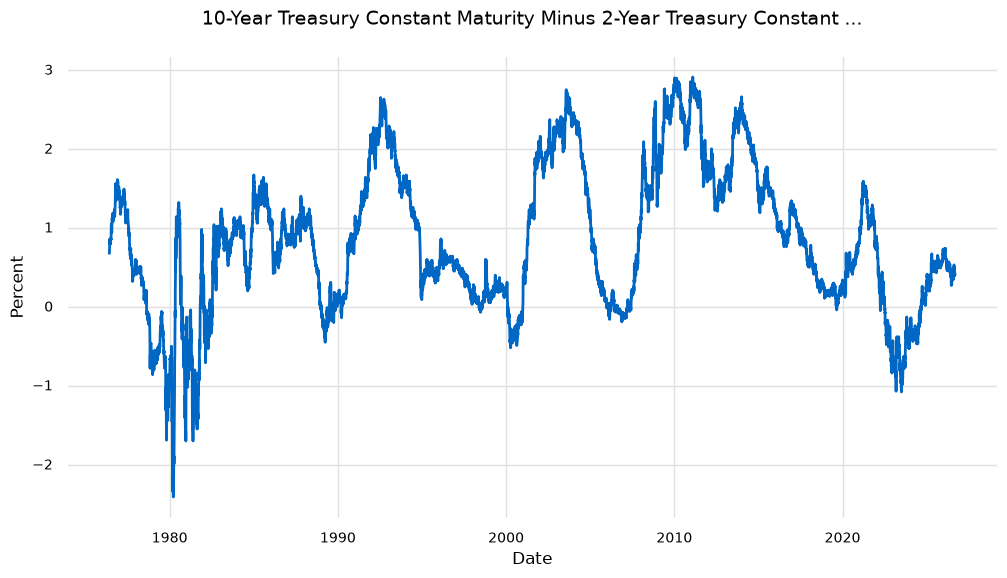

In [9]:
plot_fred_client_series(values, dates, series, figsize=(12, 6))